Train samples: 398
Test samples: 171


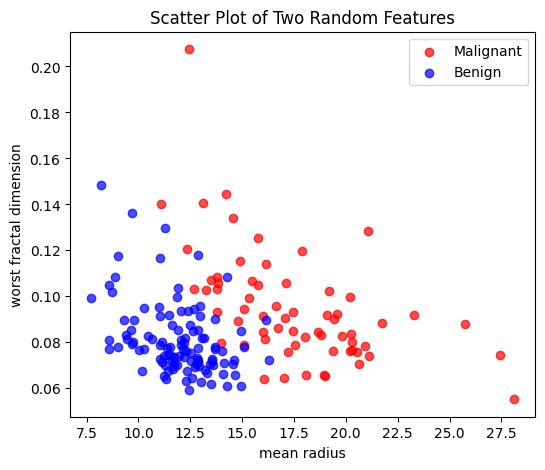

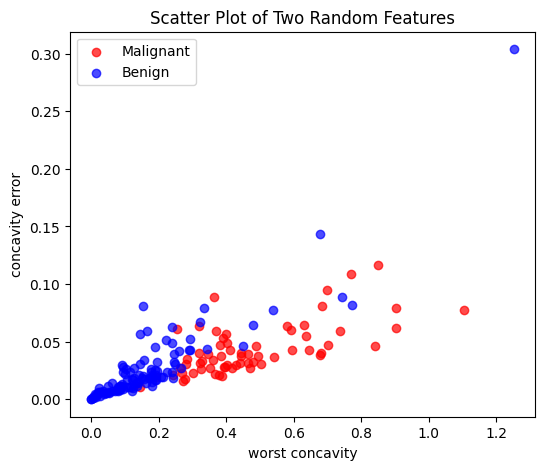

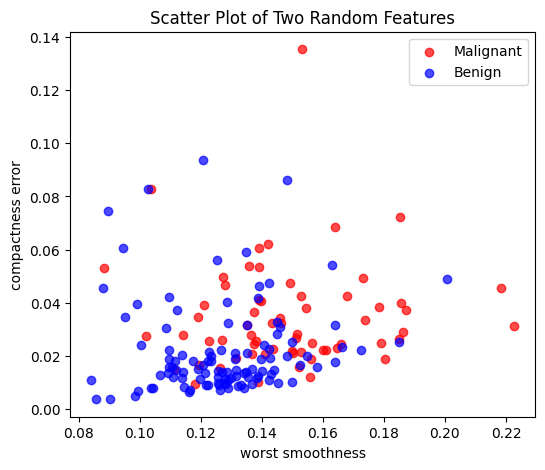

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# 2. Split into training and test sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=19, stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# 3. Visualization: Scatter plot of two random features
f1, f2, f3, f4, f5, f6   = np.random.choice(X.shape[1], 6, replace=False)
plt.figure(figsize=(6, 5))
plt.scatter(X_test[y_test == 0, f1], X_test[y_test == 0, f2], color='red', label='Malignant', alpha=0.7)
plt.scatter(X_test[y_test == 1, f1], X_test[y_test == 1, f2], color='blue', label='Benign', alpha=0.7)
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.legend()
plt.title("Scatter Plot of Two Random Features")
plt.show()
plt.figure(figsize=(6, 5))
plt.scatter(X_test[y_test == 0, f3], X_test[y_test == 0, f4], color='red', label='Malignant', alpha=0.7)
plt.scatter(X_test[y_test == 1, f3], X_test[y_test == 1, f4], color='blue', label='Benign', alpha=0.7)
plt.xlabel(feature_names[f3])
plt.ylabel(feature_names[f4])
plt.legend()
plt.title("Scatter Plot of Two Random Features")
plt.show()
plt.figure(figsize=(6, 5))
plt.scatter(X_test[y_test == 0, f5], X_test[y_test == 0, f6], color='red', label='Malignant', alpha=0.7)
plt.scatter(X_test[y_test == 1, f5], X_test[y_test == 1, f6], color='blue', label='Benign', alpha=0.7)
plt.xlabel(feature_names[f5])
plt.ylabel(feature_names[f6])
plt.legend()
plt.title("Scatter Plot of Two Random Features")
plt.show()
# 4. Normalization / Standardization
# --- Option 1: Z-Score ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [99]:
from collections import Counter
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))
class KNN:
    def __init__(self, k=3):

        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):

        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distances = []
        for i in range(len(self.X_train)):
            d = euclidean_distance(x, self.X_train[i])
            distances.append(d)

        distances = np.array(distances)
        k_indices = distances.argsort()[:self.k]
        k_labels = self.y_train[k_indices]
        label_counts = Counter(k_labels)
        most_common_label = label_counts.most_common(1)[0][0]

        return most_common_label

    def predict(self, X):
        y_pred = []
        for i in range(len(X)):
            y_pred.append(self._predict_one(X[i]))
        return np.array(y_pred)



In [100]:
class NearestMeanClassifier:
    def __init__(self):
        self.class_means = {}
        self.classes = None

    def fit(self, X, y):

        self.classes = np.unique(y)
        for c in self.classes:

            self.class_means[c] = np.mean(X[y == c], axis=0)

    def _predict_one(self, x):

        distances = {}
        for c in self.classes:
            d = np.sqrt(np.sum((x - self.class_means[c])**2))
            distances[c] = d


        return min(distances, key=distances.get)

    def predict(self, X):

        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)


In [101]:
class GaussianNaiveBayes:
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None
    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        self.means_ = np.zeros((n_classes, n_features))
        self.vars_ = np.zeros((n_classes, n_features))
        self.priors_ = np.zeros(n_classes)

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.means_[idx, :] = X_c.mean(axis=0)
            self.vars_[idx, :] = X_c.var(axis=0) + 1e-9  # +epsilon برای جلوگیری از صفر شدن
            self.priors_[idx] = X_c.shape[0] / float(n_samples)

    def _gaussian_logpdf(self, class_idx, x):

        mean = self.means_[class_idx]
        var = self.vars_[class_idx]


        # -0.5 * [ log(2πσ²) + ((x-μ)² / σ²) ]
        log_prob = -0.5 * (np.log(2.0 * np.pi * var) + ((x - mean) ** 2) / var)
        return log_prob.sum()  # جمع روی تمام ویژگی‌ها (فرض استقلال)

    def _predict_one(self, x):

        log_posteriors = []

        for idx, c in enumerate(self.classes_):
            # log P(y=c)
            log_prior = np.log(self.priors_[idx])
            # log P(x | y=c)
            log_likelihood = self._gaussian_logpdf(idx, x)
            # log P(y=c | x) ∝ log_prior + log_likelihood
            log_posteriors.append(log_prior + log_likelihood)


        best_class_idx = np.argmax(log_posteriors)
        return self.classes_[best_class_idx]

    def predict(self, X):

        return np.array([self._predict_one(x) for x in X])


In [102]:
def gaussian_kernel(u):

    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (u ** 2))
class ParzenWindowClassifier:
    def __init__(self, h=1.0):

        self.h = h
        self.classes_ = None
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):

        self.classes_ = np.unique(y)
        self.X_train = X
        self.y_train = y

    def _parzen_density(self, x, X_c):

        n, d = X_c.shape
        # فاصله بین x و هر نمونه کلاس c
        diff = (x - X_c) / self.h
        kernel_vals = gaussian_kernel(diff)
        # چگالی میانگین
        return np.mean(np.prod(kernel_vals, axis=1)) / (self.h ** d)

    def _predict_one(self, x):

        probs = []
        for c in self.classes_:
            X_c = self.X_train[self.y_train == c]
            p_x_given_c = self._parzen_density(x, X_c)
            p_c = len(X_c) / len(self.X_train)  # احتمال پیشین
            probs.append(p_x_given_c * p_c)

        return self.classes_[np.argmax(probs)]

    def predict(self, X):

        return np.array([self._predict_one(x) for x in X])



In [103]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"🔹 {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:\n", cm, "\n")

    return acc, f1, cm


In [104]:
# ---- Import or paste your classes here ----
# from my_models import KNN, NearestMeanClassifier, GaussianNaiveBayes, ParzenWindowClassifier

# ---- Initialize models ----
knn = KNN(k=5)
nmc = NearestMeanClassifier()
gnb = GaussianNaiveBayes()
pwc = ParzenWindowClassifier(h=0.5)

# ---- Evaluate each model ----
results = {}

results['KNN'] = evaluate_model(knn, X_train_scaled, y_train, X_test_scaled, y_test, "K-Nearest Neighbors")
results['NMC'] = evaluate_model(nmc, X_train_scaled, y_train, X_test_scaled, y_test, "Nearest Mean Classifier")
results['NB'] = evaluate_model(gnb, X_train_scaled, y_train, X_test_scaled, y_test, "Naive Bayes")
results['PWC'] = evaluate_model(pwc, X_train_scaled, y_train, X_test_scaled, y_test, "Parzen Window")


🔹 K-Nearest Neighbors
Accuracy: 0.9883
F1-score: 0.9907
Confusion Matrix:
 [[ 62   2]
 [  0 107]] 

🔹 Nearest Mean Classifier
Accuracy: 0.9591
F1-score: 0.9674
Confusion Matrix:
 [[ 60   4]
 [  3 104]] 

🔹 Naive Bayes
Accuracy: 0.9474
F1-score: 0.9573
Confusion Matrix:
 [[ 61   3]
 [  6 101]] 

🔹 Parzen Window
Accuracy: 0.9591
F1-score: 0.9677
Confusion Matrix:
 [[ 59   5]
 [  2 105]] 



In [105]:
import pandas as pd

# Create a results table
acc_values = [results[k][0] for k in results]
f1_values = [results[k][1] for k in results]

df_results = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': acc_values,
    'F1-score': f1_values
})

print(df_results)


  Model  Accuracy  F1-score
0   KNN  0.988304  0.990741
1   NMC  0.959064  0.967442
2    NB  0.947368  0.957346
3   PWC  0.959064  0.967742


In [106]:
train_sizes = [0.2, 0.4, 0.6, 0.8]


models = {
    "KNN": KNN(k=5),
    "Nearest Mean": NearestMeanClassifier(),
    "Naive Bayes": GaussianNaiveBayes(),
    "Parzen Window": ParzenWindowClassifier(h=0.5)
}


results = {name: {"acc": [], "f1": []} for name in models.keys()}


for size in train_sizes:
    X_sub, X_t_sub, y_sub, y_t_sub = train_test_split(
    X, y, test_size=(1-size), random_state=40, stratify=y
)
    scaler = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub)
    X_t_sub_scaled = scaler.transform(X_t_sub)


    print(f"\n📊 Training with {int(size*100)}% of data ({X_sub.shape[0]} samples)")

    for name, model in models.items():
        model.fit(X_sub_scaled, y_sub)
        y_pred = model.predict(X_t_sub_scaled)

        acc = accuracy_score(y_t_sub, y_pred)
        f1 = f1_score(y_t_sub, y_pred)

        results[name]["acc"].append(acc)
        results[name]["f1"].append(f1)

        print(f"{name:15s} | Accuracy: {acc:.3f} | F1-score: {f1:.3f}")



📊 Training with 20% of data (113 samples)
KNN             | Accuracy: 0.919 | F1-score: 0.937
Nearest Mean    | Accuracy: 0.919 | F1-score: 0.936
Naive Bayes     | Accuracy: 0.925 | F1-score: 0.940
Parzen Window   | Accuracy: 0.921 | F1-score: 0.937

📊 Training with 40% of data (227 samples)
KNN             | Accuracy: 0.959 | F1-score: 0.968
Nearest Mean    | Accuracy: 0.936 | F1-score: 0.950
Naive Bayes     | Accuracy: 0.933 | F1-score: 0.947
Parzen Window   | Accuracy: 0.965 | F1-score: 0.972

📊 Training with 60% of data (341 samples)
KNN             | Accuracy: 0.974 | F1-score: 0.979
Nearest Mean    | Accuracy: 0.947 | F1-score: 0.959
Naive Bayes     | Accuracy: 0.943 | F1-score: 0.955
Parzen Window   | Accuracy: 0.947 | F1-score: 0.958

📊 Training with 80% of data (455 samples)
KNN             | Accuracy: 0.991 | F1-score: 0.993
Nearest Mean    | Accuracy: 0.956 | F1-score: 0.966
Naive Bayes     | Accuracy: 0.965 | F1-score: 0.973
Parzen Window   | Accuracy: 0.974 | F1-score: 0.

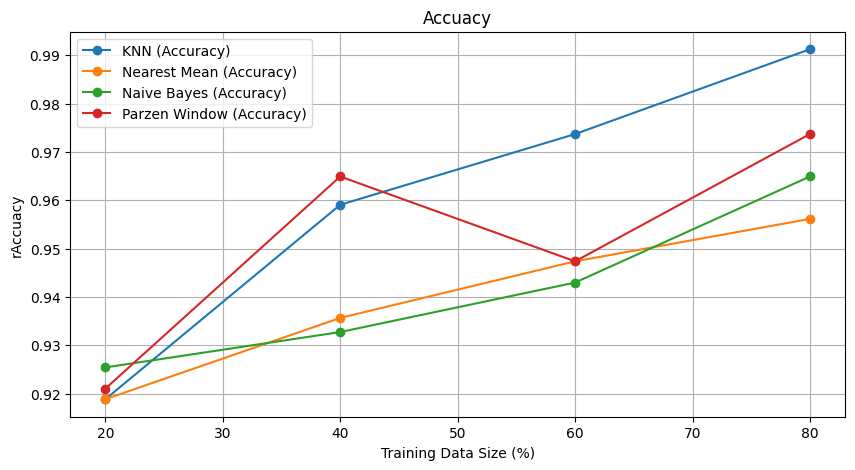

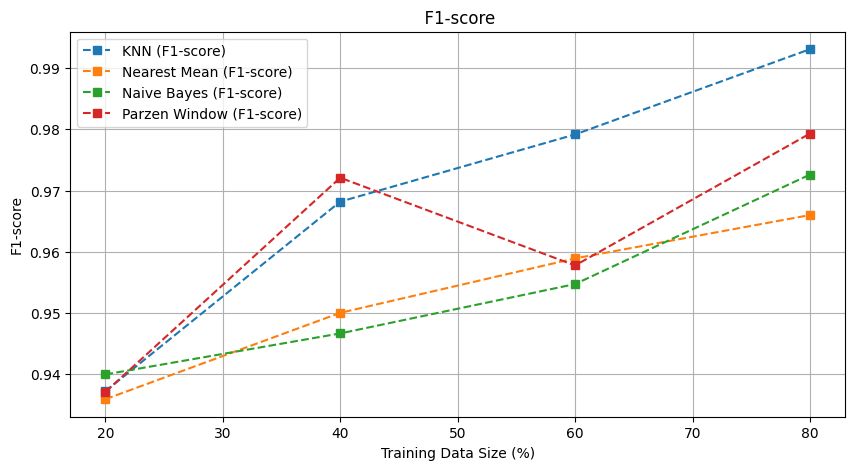

In [107]:
plt.figure(figsize=(10, 5))
for name in models.keys():
    plt.plot(np.array(train_sizes)*100, results[name]["acc"], marker='o', label=f"{name} (Accuracy)")
plt.xlabel("Training Data Size (%)")
plt.ylabel("rAccuacy")
plt.title("Accuacy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for name in models.keys():
    plt.plot(np.array(train_sizes)*100, results[name]["f1"], marker='s', linestyle='--', label=f"{name} (F1-score)")
plt.xlabel("Training Data Size (%)")
plt.ylabel("F1-score")
plt.title("  F1-score ")
plt.legend()
plt.grid(True)
plt.show()


In [108]:

def add_gaussian_noise(X, noise_level=0.005):

    X_noisy = X.copy()
    feature_range = X.max(axis=0) - X.min(axis=0)
    noise = np.random.normal(0, noise_level * feature_range, X.shape)
    return X_noisy + noise


X_test_small_noise = add_gaussian_noise(X_test_scaled, noise_level=0.05)  # نویز کوچک
X_test_big_noise   = add_gaussian_noise(X_test_scaled, noise_level=0.2)   # نویز بزرگ


results_noise = {name: {} for name in models.keys()}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_clean = model.predict(X_test_scaled)
    acc_clean = accuracy_score(y_test, y_pred_clean)
    f1_clean = f1_score(y_test, y_pred_clean)

    y_pred_small = model.predict(X_test_small_noise)
    acc_small = accuracy_score(y_test, y_pred_small)
    f1_small = f1_score(y_test, y_pred_small)

    y_pred_big = model.predict(X_test_big_noise)
    acc_big = accuracy_score(y_test, y_pred_big)
    f1_big = f1_score(y_test, y_pred_big)

    results_noise[name] = {
        "Acc_Clean": acc_clean, "F1_Clean": f1_clean,
        "Acc_Small": acc_small, "F1_Small": f1_small,
        "Acc_Big": acc_big, "F1_Big": f1_big
    }

import pandas as pd

df_noise = pd.DataFrame(results_noise).T
print(df_noise.round(3))


               Acc_Clean  F1_Clean  Acc_Small  F1_Small  Acc_Big  F1_Big
KNN                0.988     0.991      0.977     0.981    0.936   0.949
Nearest Mean       0.959     0.967      0.959     0.967    0.924   0.940
Naive Bayes        0.947     0.957      0.912     0.927    0.409   0.106
Parzen Window      0.959     0.968      0.959     0.967    0.883   0.907


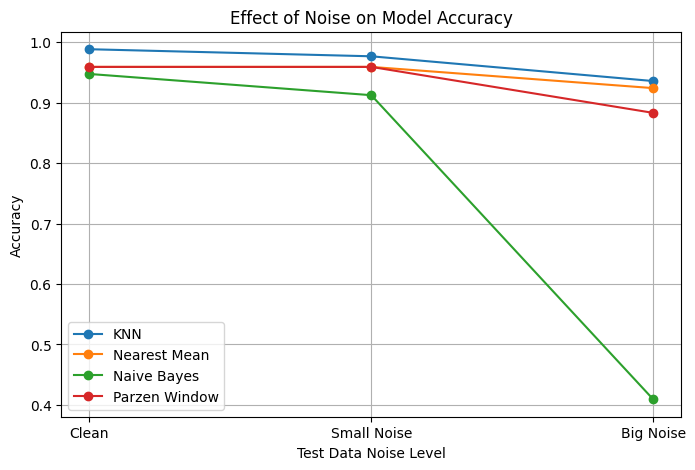

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for name in models.keys():
    plt.plot(["Clean", "Small Noise", "Big Noise"],
             [results_noise[name]["Acc_Clean"], results_noise[name]["Acc_Small"], results_noise[name]["Acc_Big"]],
             marker='o', label=name)
plt.title("Effect of Noise on Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Test Data Noise Level")
plt.legend()
plt.grid(True)
plt.show()
